In [7]:
import pandas as pd

news_df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

stock_df = pd.read_csv("../data/raw/AAPL.csv")
print("NEWS DATA")
display(news_df.head())
stock_df.head()
print("STOCK DATA")
display(stock_df.head())

NEWS DATA


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


STOCK DATA


,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [2]:
#CLEAN + CONVERT DATES (VERY IMPORTANT)
news_df["date"] = pd.to_datetime(news_df["date"], errors="coerce").dt.date

print(news_df["date"].head(10))
print(news_df["date"].isna().sum())

print(stock_df["Date"].head(10))
print(stock_df["Date"].isna().sum())

0    2020-06-05
1    2020-06-03
2    2020-05-26
3    2020-05-22
4    2020-05-22
5    2020-05-22
6    2020-05-22
7    2020-05-22
8    2020-05-22
9    2020-05-22
Name: date, dtype: object
1351341
0    2009-01-02
1    2009-01-05
2    2009-01-06
3    2009-01-07
4    2009-01-08
5    2009-01-09
6    2009-01-12
7    2009-01-13
8    2009-01-14
9    2009-01-15
Name: Date, dtype: str
0


In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

news_df["sentiment_score"] = news_df["headline"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

In [5]:
#STOCK RETURNS
stock_df = stock_df.sort_values("Date")

stock_df["daily_return"] = stock_df["Close"].pct_change() * 100

stock_daily = pd.to_datetime(stock_df["Date"]).dt.date #stock_df[["date_only", "daily_return"]].dropna()
stock_daily.head()

0    2009-01-02
1    2009-01-05
2    2009-01-06
3    2009-01-07
4    2009-01-08
Name: Date, dtype: object

In [ ]:
stock_df["daily_return"] = stock_df["Close"].pct_change()

volatility = stock_df["daily_return"].std()

cumulative_return = (1 + stock_df["daily_return"]).cumprod()

risk_free_rate = 0.01 / 252
sharpe_ratio = (
    stock_df["daily_return"].mean() - risk_free_rate
) / stock_df["daily_return"].std()

print("Volatility:", volatility)
print("Sharpe Ratio:", sharpe_ratio)

In [ ]:
news_df["date"] = pd.to_datetime(news_df["date"], errors="coerce").dt.date
stock_df["Date"] = pd.to_datetime(stock_df["Date"], errors="coerce").dt.date

In [ ]:
merged_df = pd.merge(
    daily_sentiment,
    stock_df[["Date", "daily_return"]],
    left_on="date_only",
    right_on="Date",
    how="inner"
)

In [ ]:
def classify(x):
    if x > 0.05:
        return "Positive"
    elif x < -0.05:
        return "Negative"
    return "Neutral"

merged_df["category"] = merged_df["sentiment_score"].apply(classify)

category_returns = merged_df.groupby("category")["daily_return"].mean()

category_returns.plot(kind="bar", title="Sentiment Category vs Returns")
plt.show()

In [ ]:
try:
    merged_df = merged_df.dropna()
    print("Data cleaned successfully")
except Exception as e:
    print("Error during cleaning:", e)

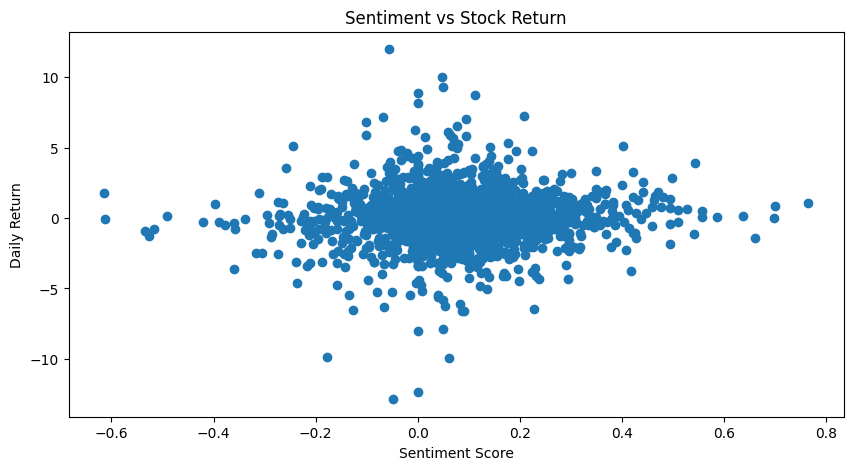

In [ ]:
#VISUALIZATION
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.scatter(merged_df["sentiment_score"], merged_df["daily_return"])
plt.title("Sentiment vs Stock Return")
plt.xlabel("Sentiment Score")
plt.ylabel("Daily Return")
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english", max_features=10)
X = vectorizer.fit_transform(news_df["headline"])

print(vectorizer.get_feature_names_out())

['52' 'companies' 'eps' 'hit' 'market' 'price' 'shares' 'stocks' 'trading'
 'week']


In [ ]:
correlation = merged_df["sentiment_score"].corr(merged_df["daily_return"])

print("Correlation between sentiment and stock return:", correlation)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

stock_df["Daily_Return"] = stock_df["Close"].pct_change()

volatility = stock_df["Daily_Return"].std()
avg_return = stock_df["Daily_Return"].mean()

stock_df["Cumulative_Return"] = (1 + stock_df["Daily_Return"]).cumprod() - 1

risk_free_rate = 0.01 / 252

sharpe_ratio = (
    (stock_df["Daily_Return"].mean() - risk_free_rate)
    / stock_df["Daily_Return"].std()
)

print("Volatility:", volatility)
print("Average Daily Return:", avg_return)
print("Sharpe Ratio:", sharpe_ratio)

Volatility: 0.018010113628161184
Average Daily Return: 0.001289109878451905
Sharpe Ratio: 0.06937365108100825


TF-IDF analysis reveals that financial news is dominated by terms such as stocks, market, shares, trading, and EPS, indicating a strong focus on market performance and company earnings. This confirms the dataset is highly relevant for financial sentiment analysis.